# Exploratory Data Analysis (EDA)
In this notebook, we perform Exploratory Data Analysis on the cleaned data (`data/processed/cleaned_data.csv`).
We will load the data, check for any anomalies, display summary statistics, and visualize key metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data
Let's load the dataset and take a look at the first few rows.

In [3]:
df = pd.read_csv('cleaned_data.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## 2. Dataset Overview
Here we check the shape, datatypes, missing values, and general summary statistics.

In [4]:
print("Dataset Shape:", df.shape)
print("\n--- Data Info ---")
df.info()

Dataset Shape: (12418, 11)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12418 entries, 0 to 12417
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12418 non-null  object        
 1   customer_id       12418 non-null  object        
 2   category          12418 non-null  object        
 3   item              12418 non-null  object        
 4   price_per_unit    12418 non-null  float64       
 5   quantity          12418 non-null  float64       
 6   total_spent       12418 non-null  float64       
 7   payment_method    12418 non-null  object        
 8   location          12418 non-null  object        
 9   transaction_date  12418 non-null  datetime64[ns]
 10  discount_applied  12418 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(6)
memory usage: 982.4+ KB


In [10]:
print("--- Summary Statistics ---")
display(df.describe(include='all'))

--- Summary Statistics ---


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied
count,12418,12418,12418,12418,12418.000000,12418.000000,12418.000000,12418,12418,12418,12418
unique,12418,25,8,200,NaN,NaN,NaN,3,2,NaN,2
top,TXN_2407494,CUST_05,Milk Products,Item_2_BEV,NaN,NaN,NaN,Cash,Online,NaN,True
freq,1,538,1571,1330,NaN,NaN,NaN,4263,6276,NaN,8311
mean,NaN,NaN,NaN,NaN,23.155701,5.502496,125.266549,NaN,NaN,2023-07-13 01:45:10.581414144,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,2022-01-01 00:00:00,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,55.000000,NaN,NaN,2022-09-30 00:00:00,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,2023-07-13 00:00:00,NaN
75%,NaN,NaN,NaN,NaN,32.000000,8.000000,182.000000,NaN,NaN,2024-04-24 00:00:00,NaN
max,NaN,NaN,NaN,NaN,41.000000,10.000000,369.000000,NaN,NaN,2025-01-18 00:00:00,NaN


In [8]:
print("--- Missing Values ---")
display(df.isnull().sum())

--- Missing Values ---


,0
transaction_id,0
customer_id,0
category,0
item,0
price_per_unit,0
quantity,0
total_spent,0
payment_method,0
location,0
transaction_date,0


## 3. Univariate Analysis
Let's examine the distributions of our key numerical and categorical variables.

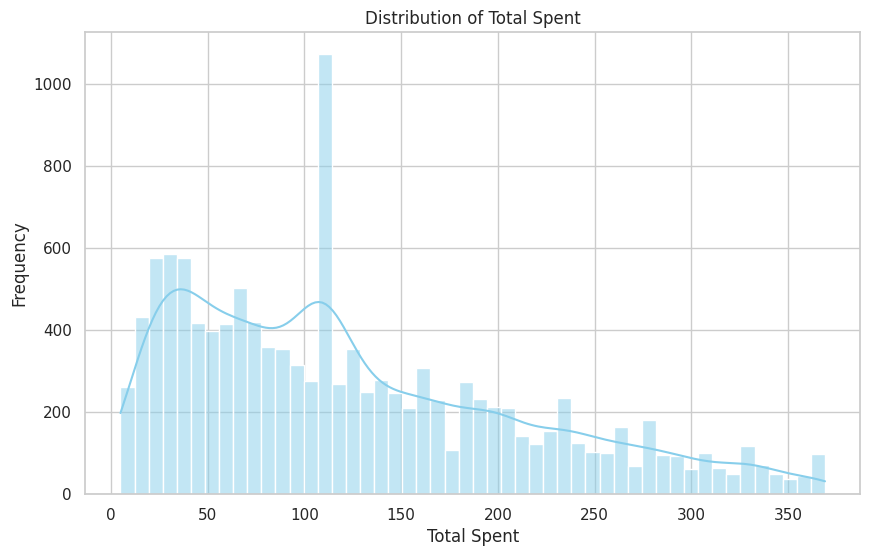

In [9]:
# Distribution of Total Spent
plt.figure(figsize=(10, 6))
sns.histplot(df['total_spent'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

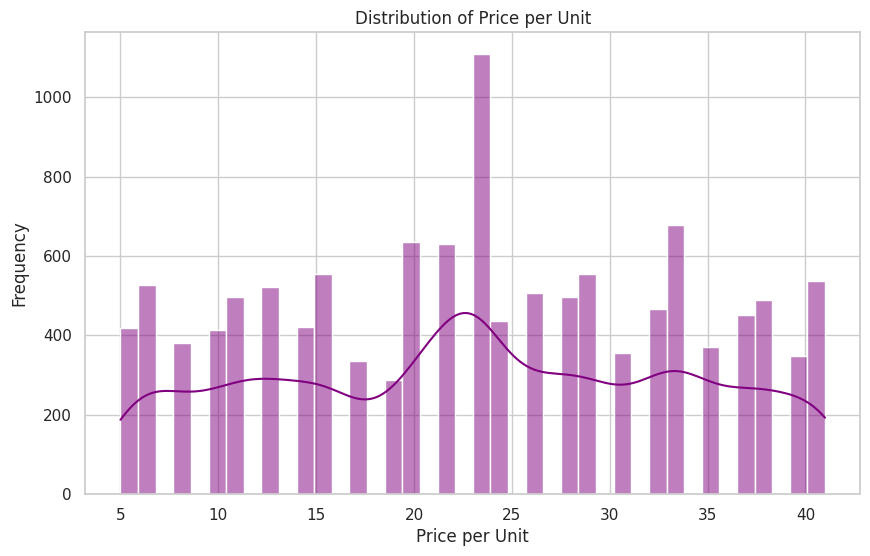

In [11]:
# Distribution of Price Per Unit
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_unit'].dropna(), bins=40, kde=True, color='purple')
plt.title('Distribution of Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_6899/393823111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='viridis')


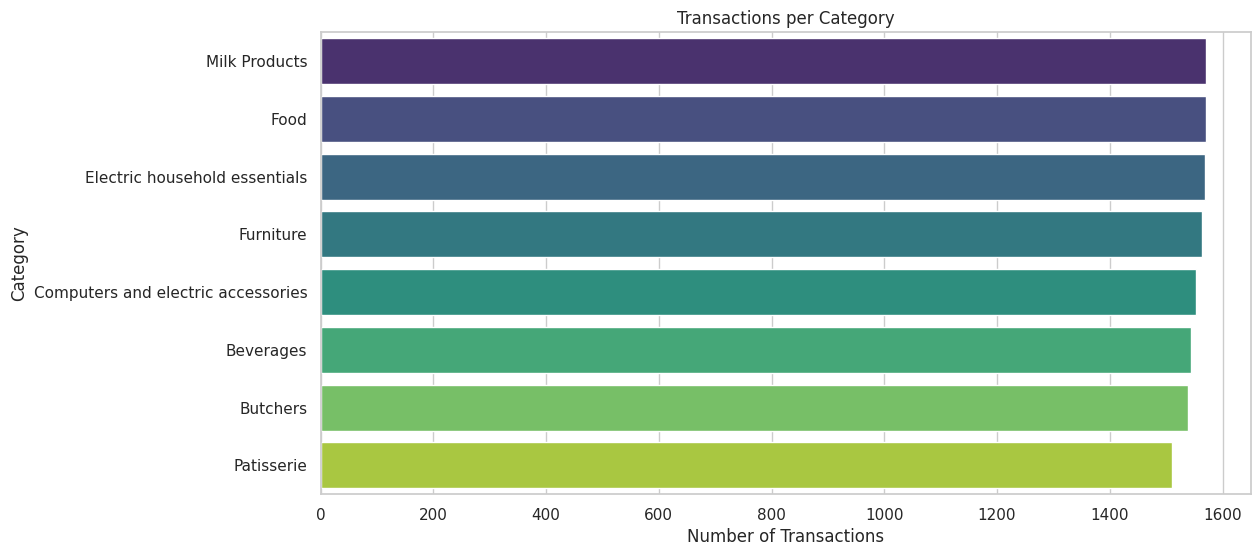

In [12]:
# Transaction Count by Category
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='viridis')
plt.title('Transactions per Category')
plt.xlabel('Number of Transactions')
plt.ylabel('Category')
plt.show()

/tmp/ipykernel_6899/1638165348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index, palette='magma')


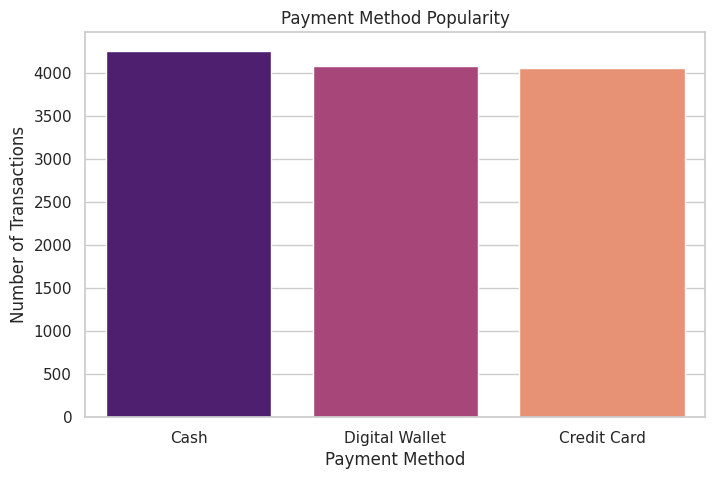

In [13]:
# Payment Methods Popularity
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index, palette='magma')
plt.title('Payment Method Popularity')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show()

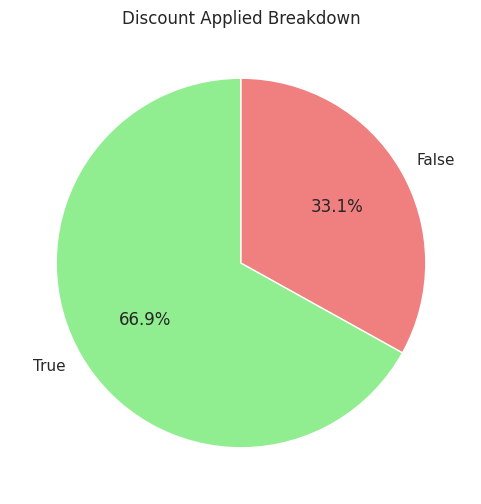

In [14]:
# Discount Applied Breakdown
plt.figure(figsize=(6, 6))
df['discount_applied'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Discount Applied Breakdown')
plt.ylabel('')
plt.show()

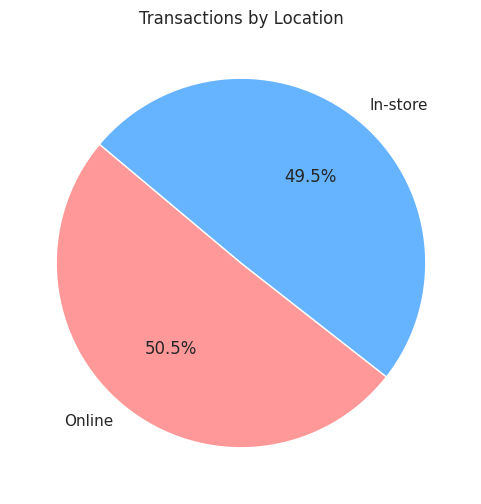

In [15]:
# Location Breakdown
plt.figure(figsize=(6, 6))
df['location'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff', '#99ff99', '#ffcc99'], startangle=140)
plt.title('Transactions by Location')
plt.ylabel('')
plt.show()

## 4. Bivariate Analysis
Investigating relationships between pairs of variables.

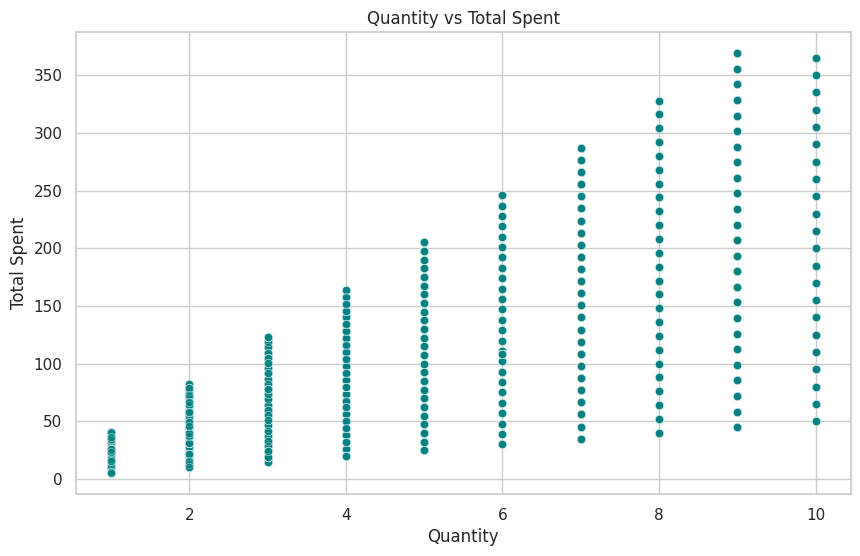

In [16]:
# Scatter Plot: Quantity vs Total Spent
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantity', y='total_spent', alpha=0.6, color='teal')
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

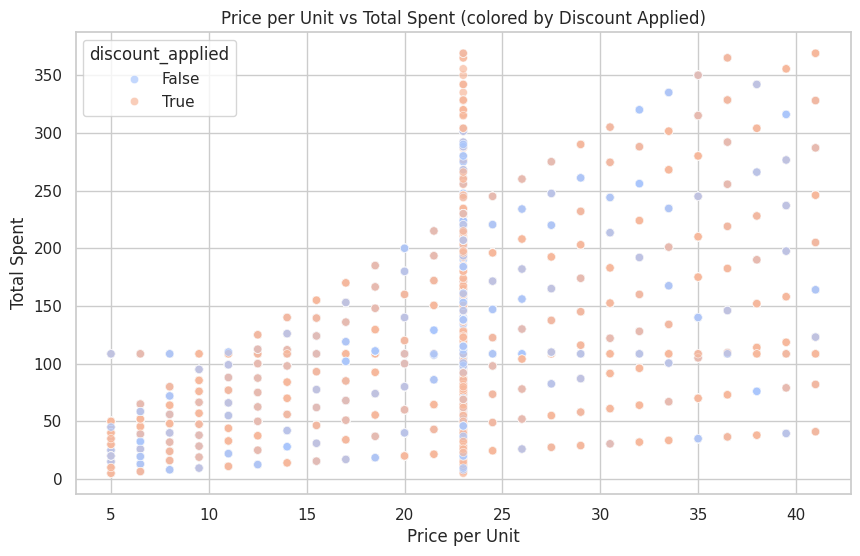

In [17]:
# Scatter Plot: Price per Unit vs Total Spent by Discount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price_per_unit', y='total_spent', hue='discount_applied', alpha=0.7, palette='coolwarm')
plt.title('Price per Unit vs Total Spent (colored by Discount Applied)')
plt.xlabel('Price per Unit')
plt.ylabel('Total Spent')
plt.show()

/tmp/ipykernel_6899/3839316230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='total_spent', y='category', palette='Set2')


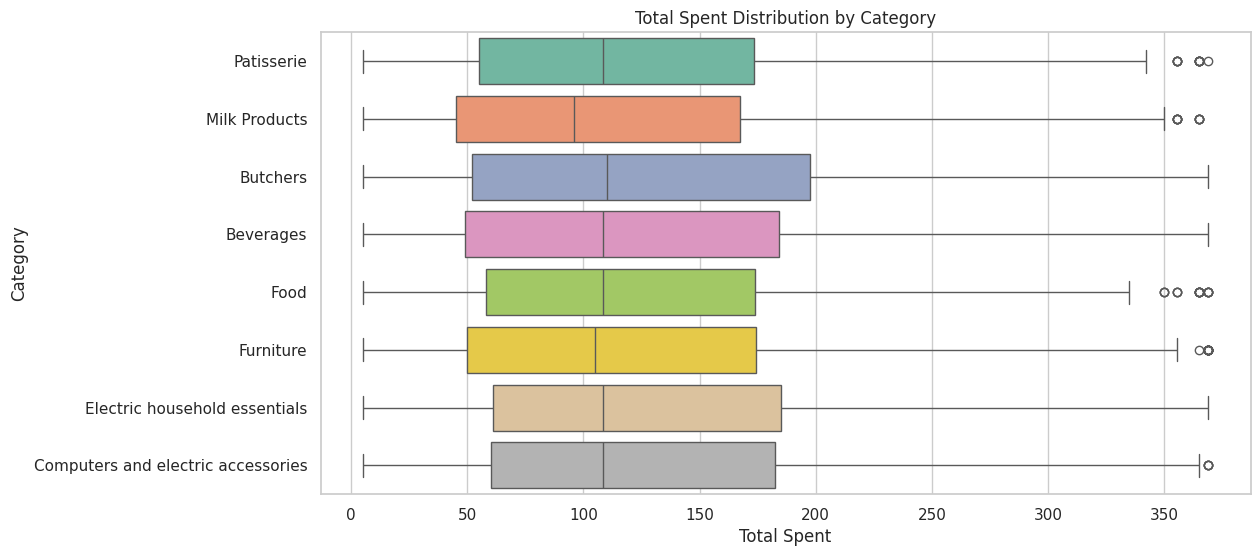

In [18]:
# Total Spent by Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='total_spent', y='category', palette='Set2')
plt.title('Total Spent Distribution by Category')
plt.xlabel('Total Spent')
plt.ylabel('Category')
plt.show()

/tmp/ipykernel_6899/2114447393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='payment_method', y='total_spent', palette='Pastel1')


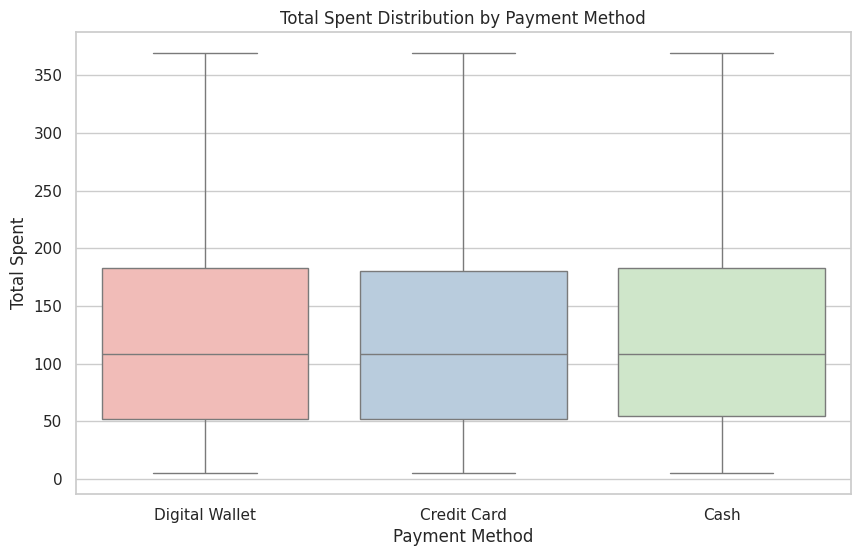

In [19]:
# Boxplot: Total Spent by Payment Method
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='payment_method', y='total_spent', palette='Pastel1')
plt.title('Total Spent Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Spent')
plt.show()

/tmp/ipykernel_6899/1163095575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='quantity', y='category', palette='muted', inner='quartile')


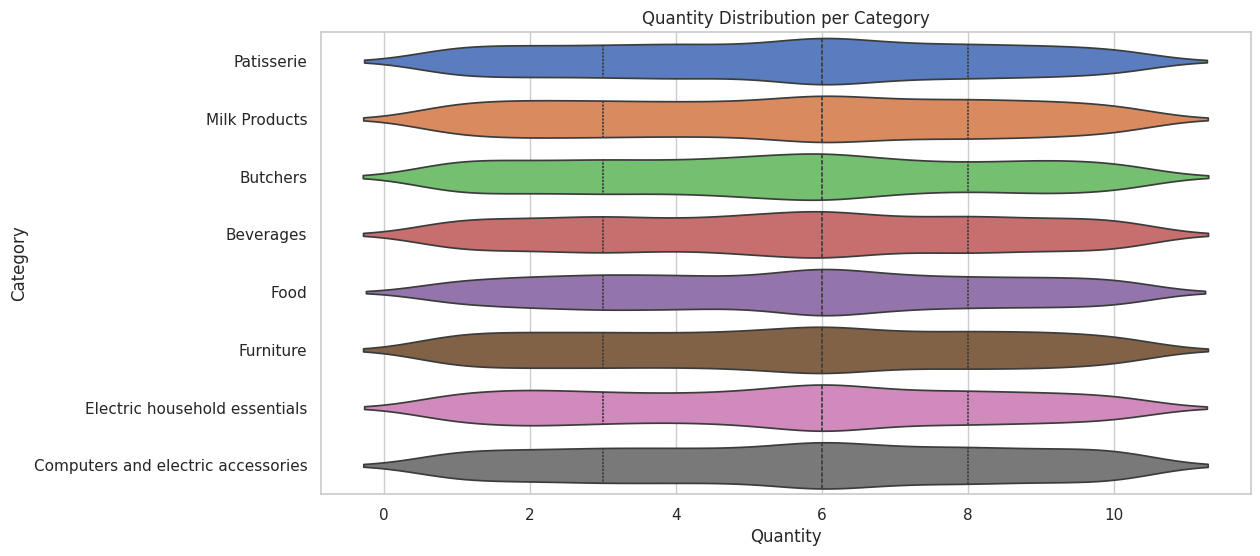

In [20]:
# Violin Plot: Quantity Distribution by Category
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='quantity', y='category', palette='muted', inner='quartile')
plt.title('Quantity Distribution per Category')
plt.xlabel('Quantity')
plt.ylabel('Category')
plt.show()

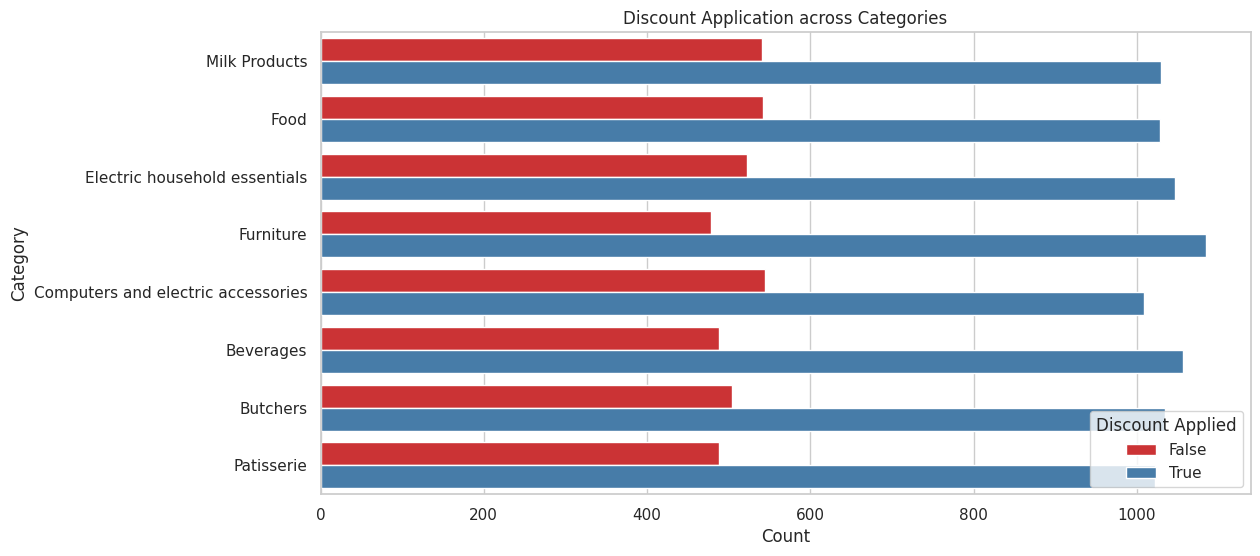

In [21]:
# Bar Chart: Category vs Discount Applied
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category', hue='discount_applied', order=df['category'].value_counts().index, palette='Set1')
plt.title('Discount Application across Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.legend(title='Discount Applied', loc='lower right')
plt.show()

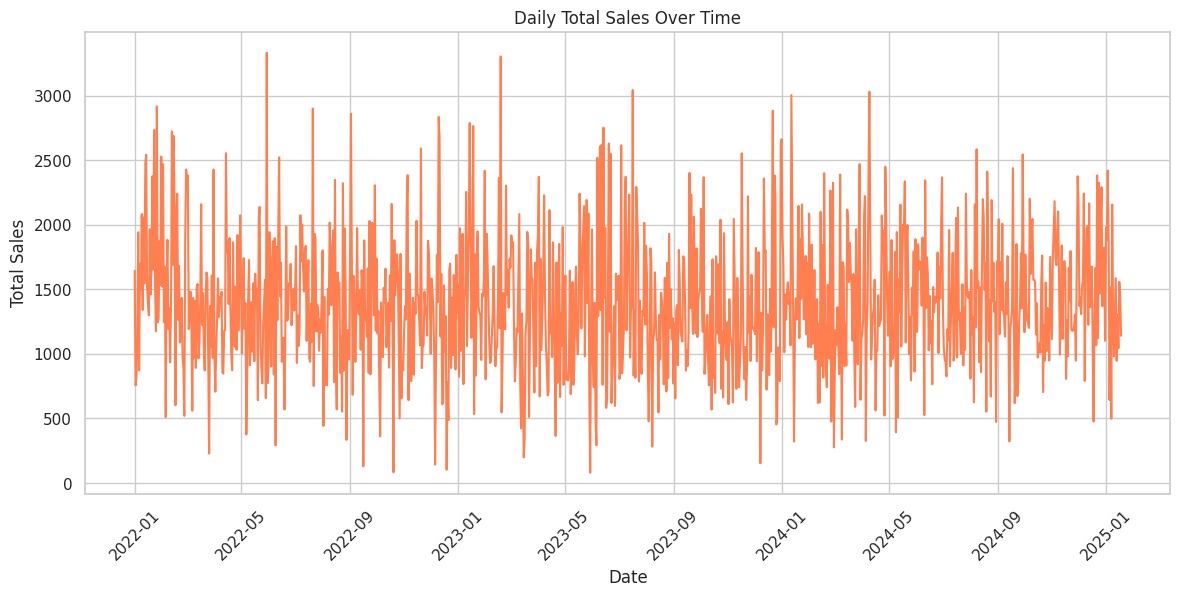

In [22]:
# Daily Sales Trend over Time
daily_sales = df.groupby('transaction_date')['total_spent'].sum().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='transaction_date', y='total_spent', color='coral')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_6899/778615833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='payment_method', y='total_spent', estimator=np.mean, errorbar=None, palette='mako')


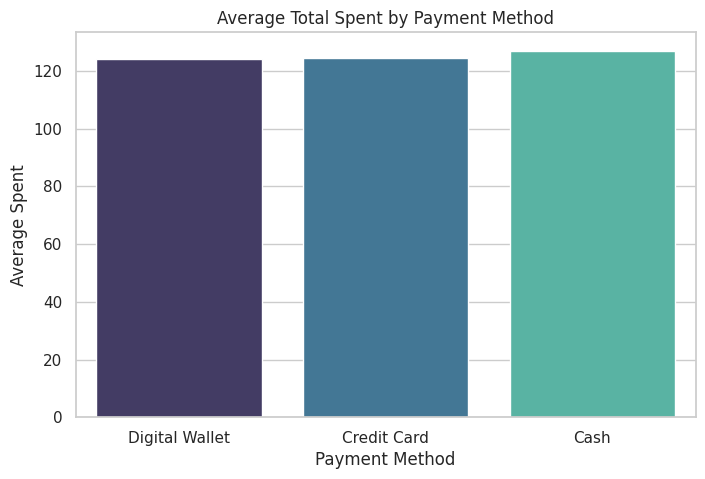

In [23]:
# Average Spend by Payment Method
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='payment_method', y='total_spent', estimator=np.mean, errorbar=None, palette='mako')
plt.title('Average Total Spent by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Spent')
plt.show()

/tmp/ipykernel_6899/1081739298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_location, x='location', y='total_spent', palette='viridis')


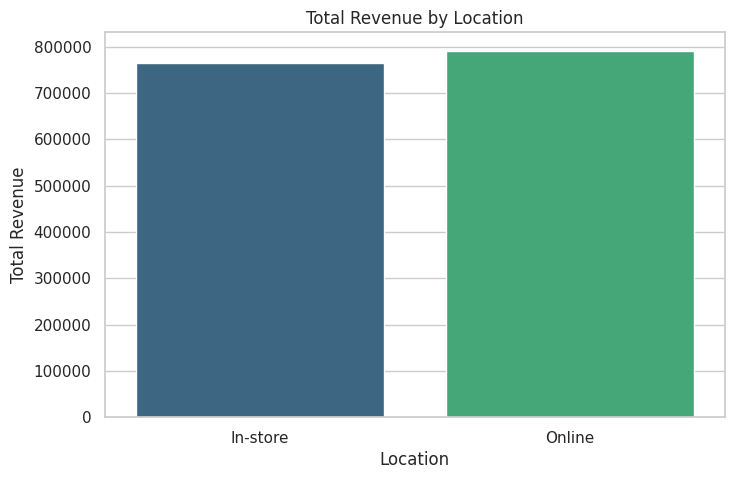

In [24]:
# Bar Chart: Total Revenue by Location
plt.figure(figsize=(8, 5))
revenue_by_location = df.groupby('location')['total_spent'].sum().reset_index()
sns.barplot(data=revenue_by_location, x='location', y='total_spent', palette='viridis')
plt.title('Total Revenue by Location')
plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.show()

## 5. Multivariate Analysis
Analyzing interactions between three or more variables.

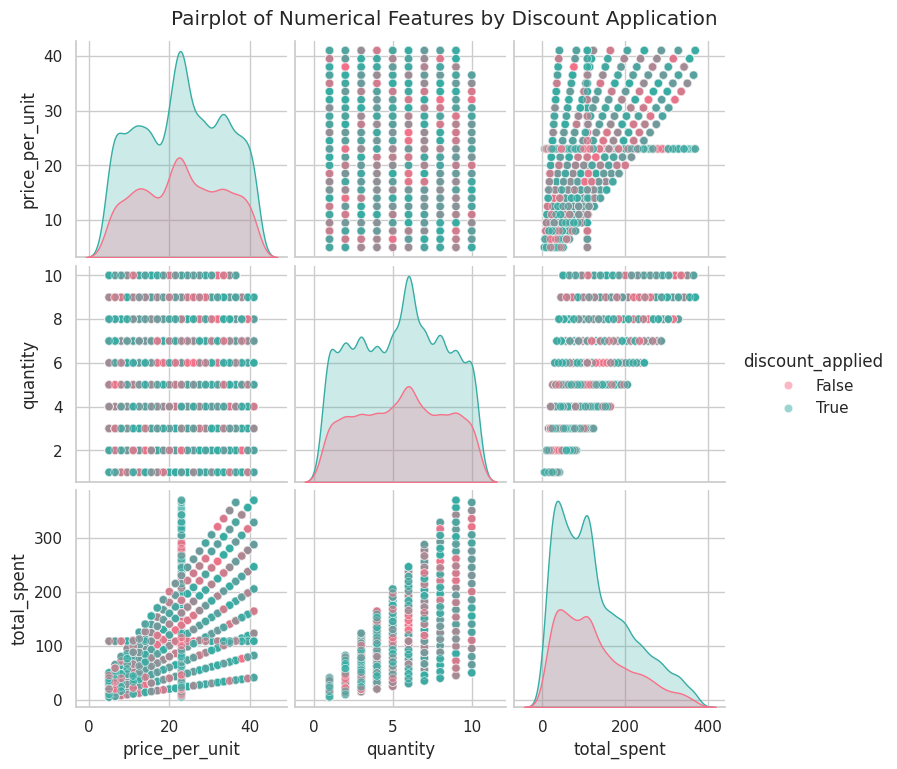

In [25]:
# Pairplot for numerical relationships
subset_cols = ['price_per_unit', 'quantity', 'total_spent', 'discount_applied']
sns.pairplot(df[subset_cols].dropna(), hue='discount_applied', palette='husl', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Numerical Features by Discount Application', y=1.02)
plt.show()

## 6. Correlation Analysis
Looking for linear relationships between numerical features.

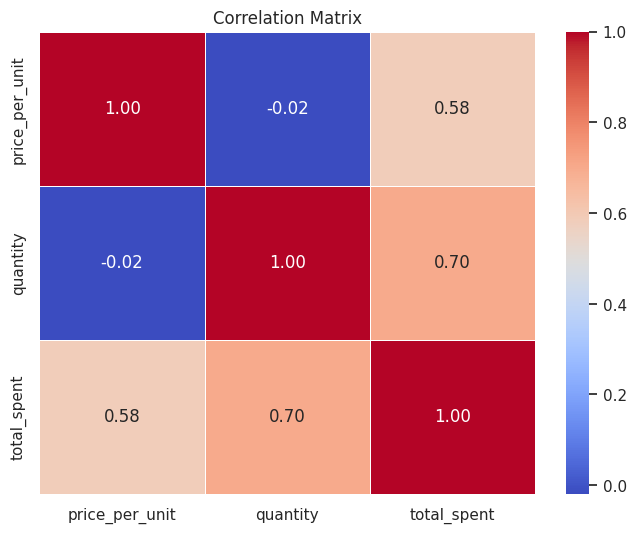

In [26]:
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()